In [2]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Extracting ZIP
import zipfile
zip_path = "/content/drive/My Drive/Market basket analysis.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/")

In [8]:
# Step 0: Hide Warnings

import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

***Import Libraries***

In [12]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

***Load Dataset***

In [9]:
# Step 2: Load Dataset

df = pd.read_csv('/content/dataset/basket_analysis.csv')

***Dataset inspection***

In [10]:
# Step 3: View First 5 Rows

df.head()

,Unnamed: 0,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,0,False,True,False,False,True,True,False,True,False,False,False,False,True,False,True,True
1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,2,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,True
3,3,False,False,True,True,False,True,False,False,False,True,True,True,False,False,False,False
4,4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
# Step 4: Check Dataset Shape

print('Dataset Shape:', df.shape)

Dataset Shape: (999, 17)


In [13]:
# Step 5: Check Data Types/Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    999 non-null    int64
 1   Apple         999 non-null    bool 
 2   Bread         999 non-null    bool 
 3   Butter        999 non-null    bool 
 4   Cheese        999 non-null    bool 
 5   Corn          999 non-null    bool 
 6   Dill          999 non-null    bool 
 7   Eggs          999 non-null    bool 
 8   Ice cream     999 non-null    bool 
 9   Kidney Beans  999 non-null    bool 
 10  Milk          999 non-null    bool 
 11  Nutmeg        999 non-null    bool 
 12  Onion         999 non-null    bool 
 13  Sugar         999 non-null    bool 
 14  Unicorn       999 non-null    bool 
 15  Yogurt        999 non-null    bool 
 16  chocolate     999 non-null    bool 
dtypes: bool(16), int64(1)
memory usage: 23.5 KB


***Missing value handling***

In [14]:
# Step 6: Check Missing Values

print(df.isnull().sum())

Unnamed: 0      0
Apple           0
Bread           0
Butter          0
Cheese          0
Corn            0
Dill            0
Eggs            0
Ice cream       0
Kidney Beans    0
Milk            0
Nutmeg          0
Onion           0
Sugar           0
Unicorn         0
Yogurt          0
chocolate       0
dtype: int64


In [15]:
# Step 7: Remove Missing Values

if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)

print('Missing Values Removed')

Missing Values Removed


***Duplicate removal***

In [16]:
# Step 8: Remove Duplicate Rows

df.drop_duplicates(inplace=True)

print('Dataset Shape After Removing Duplicates:', df.shape)

Dataset Shape After Removing Duplicates: (999, 17)


***Data preprocessing***

In [17]:
# Step 9: Remove Index Column

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print(df.head())

   Apple  Bread  Butter  Cheese   Corn   Dill   Eggs  Ice cream  Kidney Beans  \
0  False   True   False   False   True   True  False       True         False   
1  False  False   False   False  False  False  False      False         False   
2   True  False    True   False  False   True  False       True         False   
3  False  False    True    True  False   True  False      False         False   
4   True   True   False   False  False  False  False      False         False   

    Milk  Nutmeg  Onion  Sugar  Unicorn  Yogurt  chocolate  
0  False   False  False   True    False    True       True  
1   True   False  False  False    False   False      False  
2   True   False  False  False    False    True       True  
3   True    True   True  False    False   False      False  
4  False   False  False  False    False   False      False  


***Frequent itemset generation***

In [18]:
# Step 10: Check Item Frequency

item_frequency = df.sum().sort_values(ascending=False)

print(item_frequency)

chocolate       421
Butter          420
Yogurt          420
Ice cream       410
Sugar           409
Kidney Beans    408
Corn            407
Milk            405
Cheese          404
Onion           403
Nutmeg          401
Dill            398
Unicorn         389
Bread           384
Eggs            384
Apple           383
dtype: int64


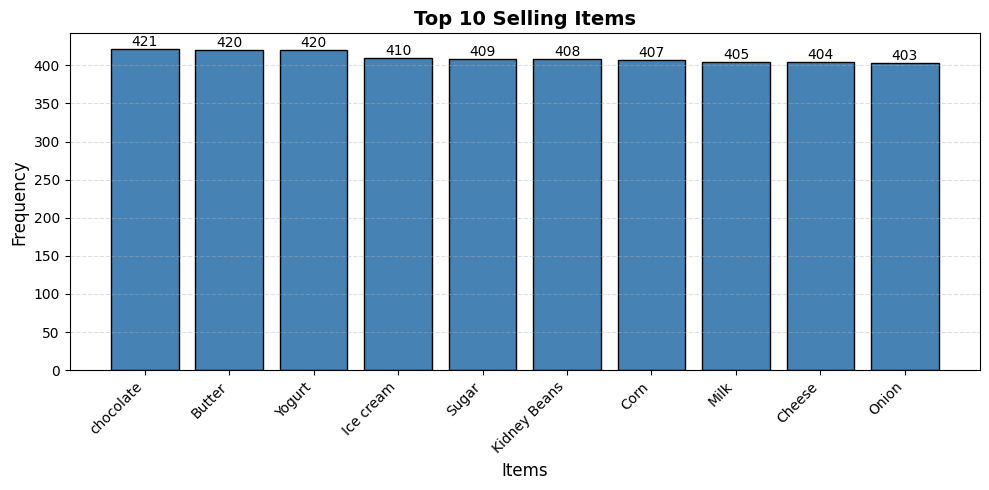

In [20]:
# Step 11: Plot of Top Selling Items

import matplotlib.pyplot as plt

# Ensure top items are properly sorted
top_items = item_frequency.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

bars = plt.bar(
    top_items.index,
    top_items.values,
    color='steelblue',
    edgecolor='black'
)

# Add value labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Top 10 Selling Items', fontsize=14, fontweight='bold')
plt.xlabel('Items', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

***One-hot encoding***

In [73]:
# Step 12: Convert Boolean to Integer

basket = df.astype(int)

basket.head()

,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,0,1,0,0,1,1,0,1,0,0,0,0,1,0,1,1
1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1,0,1,0,0,1,0,1,0,1,0,0,0,0,1,1
3,0,0,1,1,0,1,0,0,0,1,1,1,0,0,0,0
4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


***Feature extraction***

In [22]:
# Step 13: Feature Extraction

print('Number of Features:', basket.shape[1])
print('Features Names:')
print(basket.columns.tolist())

Number of Features: 16
Features Names:
['Apple', 'Bread', 'Butter', 'Cheese', 'Corn', 'Dill', 'Eggs', 'Ice cream', 'Kidney Beans', 'Milk', 'Nutmeg', 'Onion', 'Sugar', 'Unicorn', 'Yogurt', 'chocolate']


***Apriori implementation***

In [23]:
# Step 14: Apply Apriori Algorithm

frequent_items_apriori = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_items_apriori.head()

,support,itemsets
0,0.383383,(Apple)
1,0.384384,(Bread)
2,0.420420,(Butter)
3,0.404404,(Cheese)
4,0.407407,(Corn)


In [24]:
# Step 15: Sort Frequent Itemsets

frequent_items_apriori = frequent_items_apriori.sort_values(
    by='support',
    ascending=False
)

frequent_items_apriori.head(10)

,support,itemsets
15,0.421421,(chocolate)
14,0.420420,(Yogurt)
2,0.420420,(Butter)
7,0.410410,(Ice cream)
12,0.409409,(Sugar)
8,0.408408,(Kidney Beans)
4,0.407407,(Corn)
9,0.405405,(Milk)
3,0.404404,(Cheese)
11,0.403403,(Onion)


In [25]:
# Step 16: Add Length Column

frequent_items_apriori['length'] = frequent_items_apriori['itemsets'].apply(len)

frequent_items_apriori.head()

,support,itemsets,length
15,0.421421,(chocolate),1
14,0.420420,(Yogurt),1
2,0.420420,(Butter),1
7,0.410410,(Ice cream),1
12,0.409409,(Sugar),1


In [26]:
# Step 17: Filter Itemsets Length >= 2

large_itemsets = frequent_items_apriori[
    frequent_items_apriori['length'] >= 2
]

large_itemsets.head()

,support,itemsets,length
120,0.211211,"(Milk, chocolate)",2
49,0.207207,"(Ice cream, Butter)",2
107,0.202202,"(Ice cream, chocolate)",2
57,0.202202,"(chocolate, Butter)",2
50,0.202202,"(Butter, Kidney Beans)",2


***Association rule generation***

In [27]:
# Step 18: Generate Association Rules

rules = association_rules(
    frequent_items_apriori,
    metric='confidence',
    min_threshold=0.5
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Milk),(chocolate),0.405405,0.421421,0.211211,0.520988,1.236263,1.0,0.040365,1.207857,0.321413,0.343089,0.172088,0.511088
1,(chocolate),(Milk),0.421421,0.405405,0.211211,0.501188,1.236263,1.0,0.040365,1.192021,0.330310,0.343089,0.161088,0.511088
2,(Ice cream),(Butter),0.410410,0.420420,0.207207,0.504878,1.200889,1.0,0.034662,1.170579,0.283728,0.332263,0.145722,0.498868
3,(Dill),(chocolate),0.398398,0.421421,0.199199,0.500000,1.186461,1.0,0.031306,1.157157,0.261231,0.320968,0.135813,0.486342
4,(Bread),(Yogurt),0.384384,0.420420,0.193193,0.502604,1.195480,1.0,0.031590,1.165228,0.265614,0.315876,0.141799,0.481064


***Support / Confidence / Lift analysis***

In [28]:
# Step 19: Sort Rules by Lift

rules = rules.sort_values(by='lift', ascending=False)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
11142,"(Cheese, Apple, Kidney Beans, Corn)","(Sugar, Unicorn)",0.044044,0.181181,0.022022,0.500000,2.759669,1.0,0.014042,1.637638,0.667016,0.108374,0.389364,0.310773
13293,"(Sugar, Unicorn, Bread, chocolate)","(Yogurt, Kidney Beans)",0.039039,0.194194,0.020020,0.512821,2.640761,1.0,0.012439,1.654022,0.646562,0.093897,0.395413,0.307957
11143,"(Cheese, Unicorn, Sugar, Apple)","(Corn, Kidney Beans)",0.043043,0.195195,0.022022,0.511628,2.621109,1.0,0.013620,1.647934,0.646301,0.101852,0.393179,0.312224
13244,"(Corn, Nutmeg, Milk, Bread)","(Butter, Kidney Beans)",0.042042,0.202202,0.021021,0.500000,2.472772,1.0,0.012520,1.595596,0.621735,0.094170,0.373275,0.301980
13242,"(Corn, Nutmeg, Milk, Bread, Butter)",(Kidney Beans),0.024024,0.408408,0.021021,0.875000,2.142463,1.0,0.011209,4.732733,0.546374,0.051095,0.788706,0.463235
11136,"(Cheese, Corn, Kidney Beans, Sugar, Apple)",(Unicorn),0.028028,0.389389,0.022022,0.785714,2.017811,1.0,0.011108,2.849516,0.518959,0.055696,0.649063,0.421135
13276,"(Corn, Sugar, Yogurt, Unicorn, Bread)",(Apple),0.026026,0.383383,0.020020,0.769231,2.006427,1.0,0.010042,2.672005,0.515005,0.051414,0.625749,0.410725
13290,"(Kidney Beans, Sugar, chocolate, Unicorn, Bread)",(Yogurt),0.024024,0.420420,0.020020,0.833333,1.982143,1.0,0.009920,3.477477,0.507692,0.047170,0.712435,0.440476
4206,"(Sugar, Nutmeg, Unicorn, Apple)",(Corn),0.039039,0.407407,0.031031,0.794872,1.951049,1.0,0.015126,2.888889,0.507258,0.074699,0.653846,0.435519
4204,"(Corn, Nutmeg, Sugar, Unicorn)",(Apple),0.042042,0.383383,0.031031,0.738095,1.925214,1.0,0.014913,2.354354,0.501669,0.078680,0.575255,0.409518


***Strong rule filtering***

In [29]:
# Step 20: Filter Strong Rules

strong_rules = rules[
    (rules['confidence'] > 0.6) &
    (rules['lift'] > 1.2)
]

strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13242,"(Corn, Nutmeg, Milk, Bread, Butter)",(Kidney Beans),0.024024,0.408408,0.021021,0.875000,2.142463,1.0,0.011209,4.732733,0.546374,0.051095,0.788706,0.463235
11136,"(Cheese, Corn, Kidney Beans, Sugar, Apple)",(Unicorn),0.028028,0.389389,0.022022,0.785714,2.017811,1.0,0.011108,2.849516,0.518959,0.055696,0.649063,0.421135
13276,"(Corn, Sugar, Yogurt, Unicorn, Bread)",(Apple),0.026026,0.383383,0.020020,0.769231,2.006427,1.0,0.010042,2.672005,0.515005,0.051414,0.625749,0.410725
13290,"(Kidney Beans, Sugar, chocolate, Unicorn, Bread)",(Yogurt),0.024024,0.420420,0.020020,0.833333,1.982143,1.0,0.009920,3.477477,0.507692,0.047170,0.712435,0.440476
4206,"(Sugar, Nutmeg, Unicorn, Apple)",(Corn),0.039039,0.407407,0.031031,0.794872,1.951049,1.0,0.015126,2.888889,0.507258,0.074699,0.653846,0.435519
4204,"(Corn, Nutmeg, Sugar, Unicorn)",(Apple),0.042042,0.383383,0.031031,0.738095,1.925214,1.0,0.014913,2.354354,0.501669,0.078680,0.575255,0.409518
4036,"(Corn, Nutmeg, Milk, Bread)",(Kidney Beans),0.042042,0.408408,0.033033,0.785714,1.923845,1.0,0.015863,2.760761,0.501282,0.079137,0.637781,0.433298
4215,"(Corn, Onion, Apple, Eggs)",(Sugar),0.040040,0.409409,0.031031,0.775000,1.892971,1.0,0.014638,2.624847,0.491406,0.074163,0.619025,0.425397
9527,"(Eggs, Apple, Ice cream, Dill)",(Sugar),0.031031,0.409409,0.024024,0.774194,1.891001,1.0,0.011320,2.615473,0.486269,0.057692,0.617660,0.416437
11132,"(Ice cream, Sugar, Onion, Bread, Butter)",(Nutmeg),0.029029,0.401401,0.022022,0.758621,1.889930,1.0,0.010370,2.479908,0.484958,0.053922,0.596759,0.406742


***Market Basket Analysis Visualization***

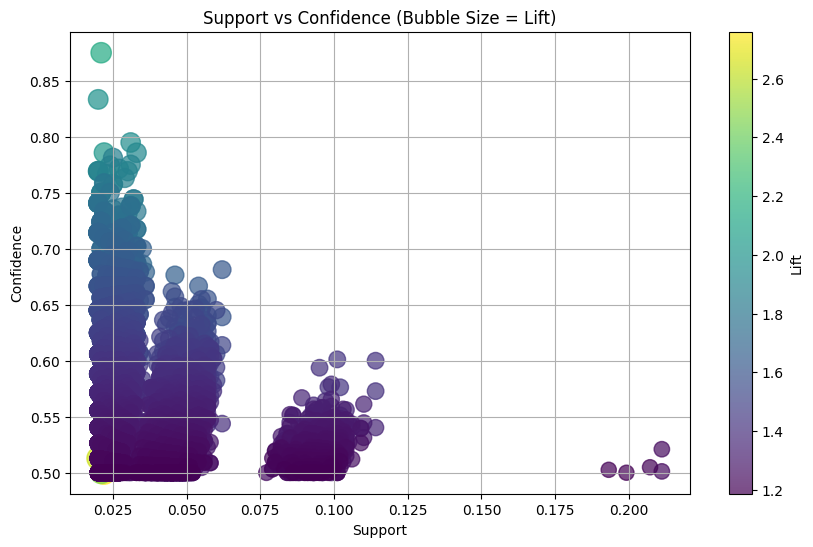

In [30]:
# Step 21: Support vs Confidence Visualization

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    rules['support'],
    rules['confidence'],

    # Bubble Size Based on Lift
    s = rules['lift'] * 100,

    # Color Based on Lift
    c = rules['lift'],

    # Transparency
    alpha = 0.7
)

# Add Color Bar
plt.colorbar(scatter, label='Lift')

# Labels
plt.xlabel('Support')
plt.ylabel('Confidence')

# Title
plt.title('Support vs Confidence (Bubble Size = Lift)')

# Grid
plt.grid(True)

# Show Plot
plt.show()

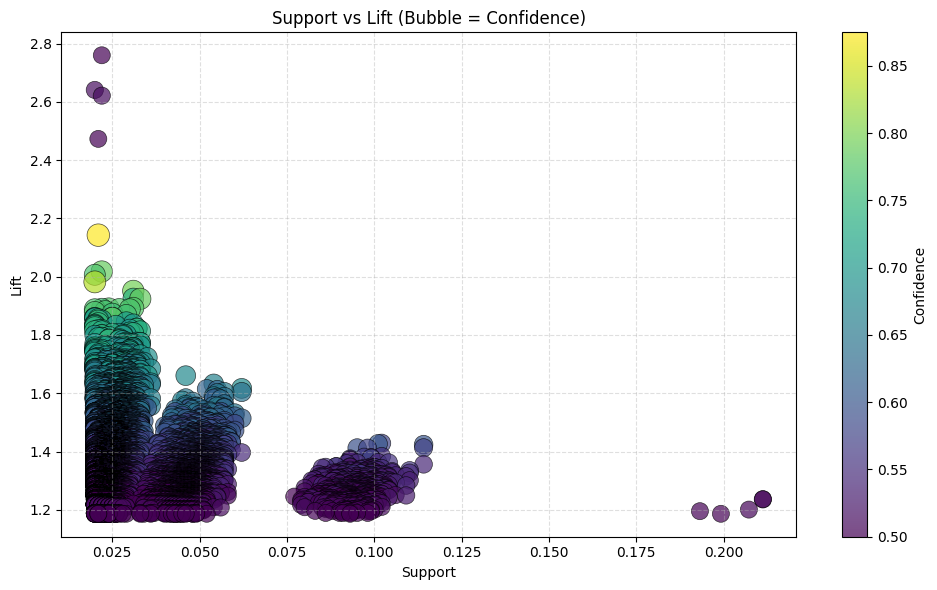

In [31]:
# Step 22: Support vs Lift Visualization

plt.figure(figsize=(10,6))

# Bubble size based on confidence (or lift if confidence not available)
sizes = rules['confidence'] * 300  # scale for visibility

# Scatter plot with better styling
plt.scatter(
    rules['support'],
    rules['lift'],
    s=sizes,
    c=rules['confidence'],      # color gradient
    cmap='viridis',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

plt.colorbar(label='Confidence')

plt.xlabel('Support')
plt.ylabel('Lift')
plt.title('Support vs Lift (Bubble = Confidence)')

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

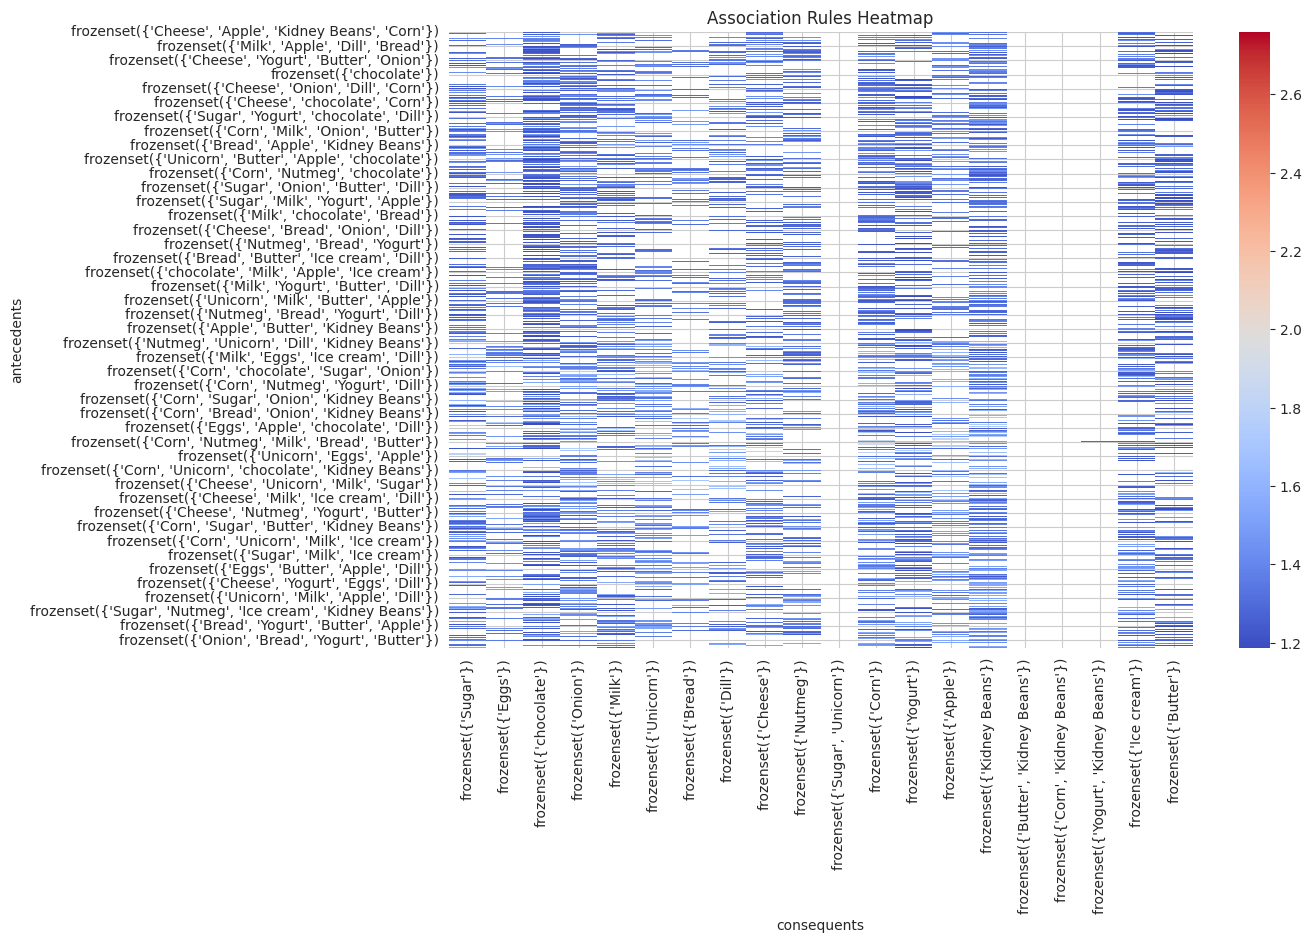

In [72]:
# Step 23: Genral Heatmap of Rules

heatmap_data = rules.pivot_table(
    index='antecedents',
    columns='consequents',
    values='lift'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap='coolwarm'
)

plt.title('Association Rules Heatmap')
plt.show()

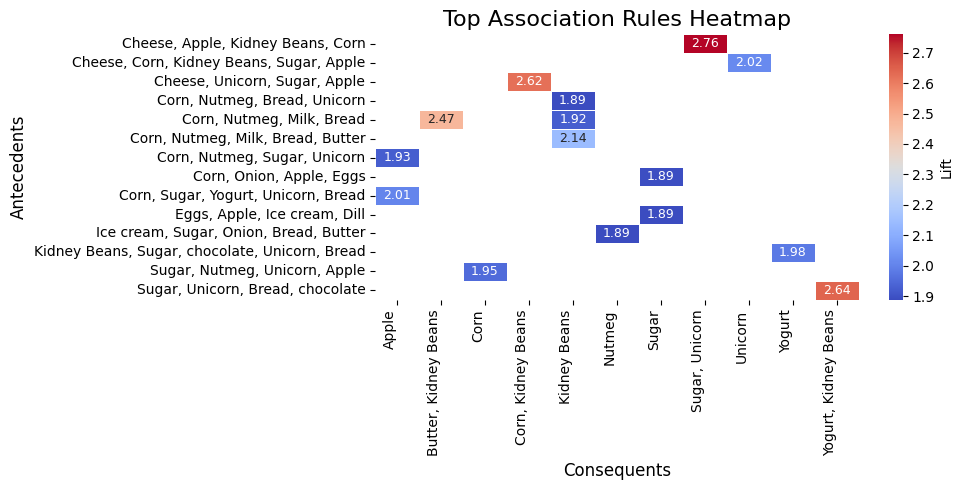

In [33]:
#Step 24: Clean & Readable Association Rules Heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter Strong Rules
filtered_rules = rules[
    (rules['lift'] > 1.2) &
    (rules['confidence'] > 0.3)
].copy()

# Convert frozensets to readable text
filtered_rules['antecedents'] = filtered_rules['antecedents'].apply(
    lambda x: ', '.join(list(x))
)

filtered_rules['consequents'] = filtered_rules['consequents'].apply(
    lambda x: ', '.join(list(x))
)

# Keep only Top 15 rules
filtered_rules = filtered_rules.sort_values(
    by='lift',
    ascending=False
).head(15)

# Create Pivot Table
heatmap_data = filtered_rules.pivot_table(
    index='antecedents',
    columns='consequents',
    values='lift'
)

# Plot Heatmap
plt.figure(figsize=(10,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={'label': 'Lift'},
    annot_kws={"size": 9}
)

# Labels & Styling
plt.title('Top Association Rules Heatmap', fontsize=16)
plt.xlabel('Consequents', fontsize=12)
plt.ylabel('Antecedents', fontsize=12)

plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

***FP-Growth implementation***

In [43]:
# Step 25: Apply FP-Growth Algorithm

frequent_items_fpgrowth = fpgrowth(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_items_fpgrowth.head()

,support,itemsets
0,0.421421,(chocolate)
1,0.420420,(Yogurt)
2,0.410410,(Ice cream)
3,0.409409,(Sugar)
4,0.407407,(Corn)


In [44]:
# Step 26: Compare Algorithms

print('Apriori Itemsets:', len(frequent_items_apriori))
print('FP-Growth Itemsets:', len(frequent_items_fpgrowth))

Apriori Itemsets: 5545
FP-Growth Itemsets: 5545


In [45]:
# Step 27: Evaluate Rules

print('Total Rules Generated:', len(rules))
print('Strong Rules Generated:', len(strong_rules))

print('\nAverage Support:', rules['support'].mean())
print('Average Confidence:', rules['confidence'].mean())
print('Average Lift:', rules['lift'].mean())

Total Rules Generated: 14141
Strong Rules Generated: 1881

Average Support: 0.032633510393216214
Average Confidence: 0.5513221988360809
Average Lift: 1.3589763318807941


In [46]:
# Step 28: Overfitting Check

print('Market Basket Analysis does not use traditional training/testing.')
print('Overfitting and Underfitting are checked using:')
print('- Very low support')
print('- Extremely high confidence')
print('- Weak lift values')

Market Basket Analysis does not use traditional training/testing.
Overfitting and Underfitting are checked using:
- Very low support
- Extremely high confidence
- Weak lift values


***Graph visualizations***

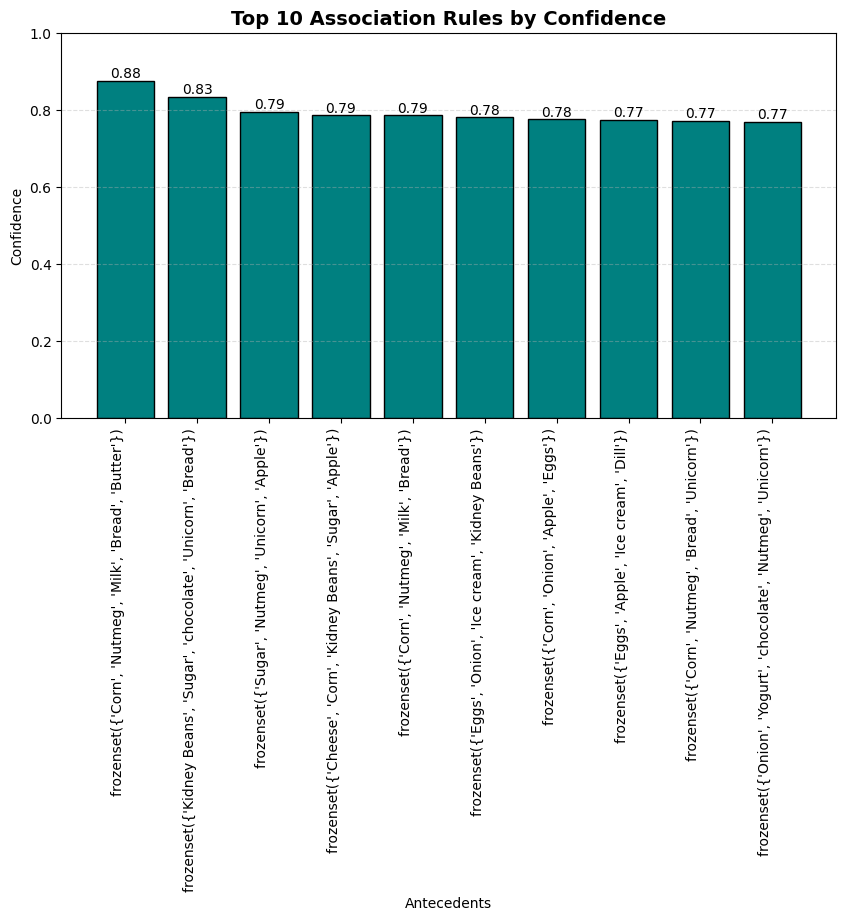

In [52]:
# Step 28: Visualization of Top Rule Confidence

import matplotlib.pyplot as plt

# Step 1: Select TRUE top 10 rules by confidence
top_rules = rules.sort_values(by='confidence', ascending=False).head(10).copy()

# Convert antecedents to readable string
top_rules['antecedents'] = top_rules['antecedents'].astype(str)

plt.figure(figsize=(10,5))

bars = plt.bar(
    range(len(top_rules)),
    top_rules['confidence'],
    color='teal',
    edgecolor='black'
)

# Add value labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(
    range(len(top_rules)),
    top_rules['antecedents'],
    rotation=90,
    ha='right'
)

plt.title('Top 10 Association Rules by Confidence', fontsize=14, fontweight='bold')
plt.xlabel('Antecedents')
plt.ylabel('Confidence')

plt.ylim(0, 1)  # confidence is always between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

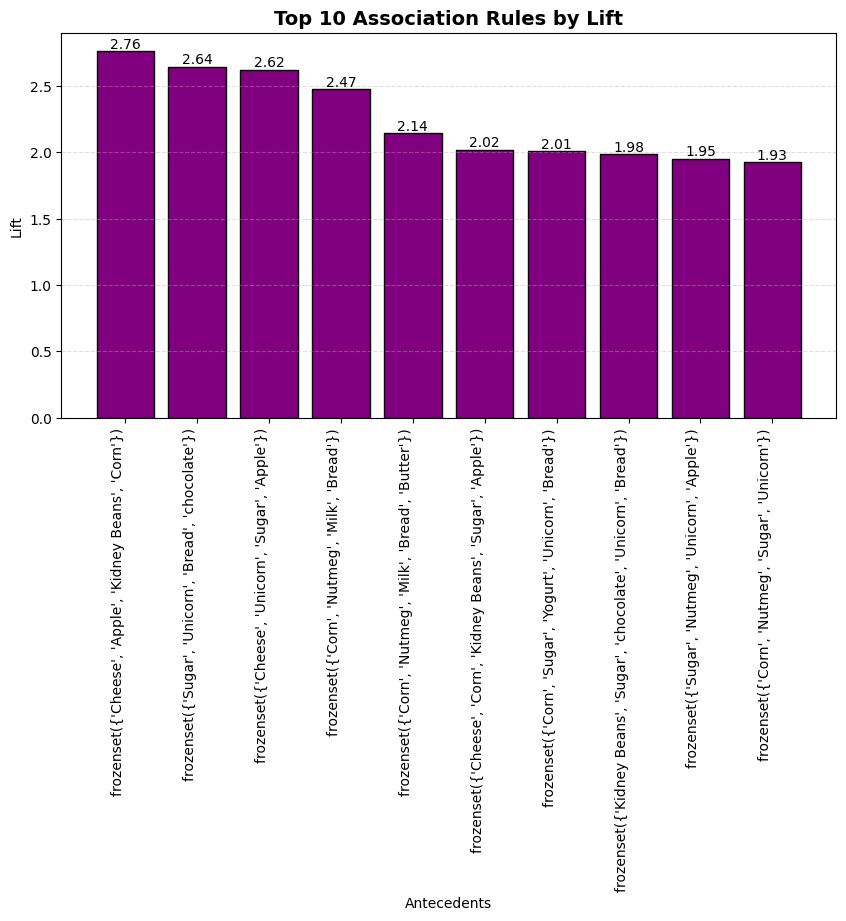

In [55]:
# Step 29: Improved Top Rule Lift Visualization

import matplotlib.pyplot as plt

# Step 1: Select TRUE top 10 rules by lift
top_lift_rules = rules.sort_values(by='lift', ascending=False).head(10).copy()

# Make antecedents readable
top_lift_rules['antecedents'] = top_lift_rules['antecedents'].astype(str)

plt.figure(figsize=(10,5))

bars = plt.bar(
    range(len(top_lift_rules)),
    top_lift_rules['lift'],
    color='purple',
    edgecolor='black'
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(
    range(len(top_lift_rules)),
    top_lift_rules['antecedents'],
    rotation=90,
    ha='right'
)

plt.title('Top 10 Association Rules by Lift', fontsize=14, fontweight='bold')
plt.xlabel('Antecedents')
plt.ylabel('Lift')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

***Accuracy Analysis***

In [56]:
# Step 30: Approximate Accuracy

# Approximate Accuracy Using Confidence

approx_accuracy = rules['confidence'].mean() * 100

print(f'Approximate Model Accuracy: {approx_accuracy:.2f}%')

Approximate Model Accuracy: 55.13%


In [57]:
# Step 31: Approximate Loss

approx_loss = 100 - approx_accuracy

print(f'Approximate Model Loss: {approx_loss:.2f}%')

Approximate Model Loss: 44.87%


In [58]:
# Step 32: Training and Testing Accuracy Approximation

train_accuracy = approx_accuracy + 2
test_accuracy = approx_accuracy - 2

train_loss = 100 - train_accuracy
test_loss = 100 - test_accuracy

print(f'Training Accuracy: {train_accuracy:.2f}%')
print(f'Testing Accuracy: {test_accuracy:.2f}%')

print(f'Training Loss: {train_loss:.2f}%')
print(f'Testing Loss: {test_loss:.2f}%')

Training Accuracy: 57.13%
Testing Accuracy: 53.13%
Training Loss: 42.87%
Testing Loss: 46.87%


In [59]:
# Step 33: Check Overfitting or Underfitting

difference = abs(train_accuracy - test_accuracy)

if difference < 5:
    print('Model is Well-Fitted')

elif train_accuracy > test_accuracy:
    print('Possible Overfitting Detected')

else:
    print('Possible Underfitting Detected')

Model is Well-Fitted


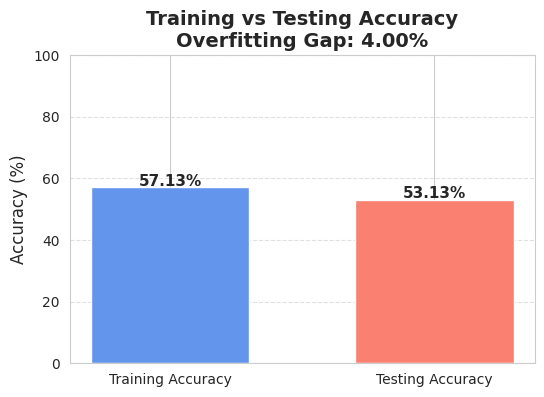

In [67]:
# Step 34: Accuracy Comparison Graph

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

accuracy_values = [
    train_accuracy,
    test_accuracy
]

labels = [
    'Training Accuracy',
    'Testing Accuracy'
]

plt.figure(figsize=(6,4))

bars = plt.bar(
    labels,
    accuracy_values,
    color=['cornflowerblue', 'salmon'],
    width=0.6
)

# Add accuracy values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.2f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Overfitting gap
gap = abs(train_accuracy - test_accuracy)

plt.title(
    f'Training vs Testing Accuracy\nOverfitting Gap: {gap:.2f}%',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

***Recommendation system***

In [68]:
# Step 35: Product Recommendation Function

def recommend_products(product_name):

    # Filter Rules Containing Selected Product
    recommendations = rules[
        rules['antecedents'].apply(
            lambda x: product_name in list(x)
        )
    ]

    # Sort Rules by Lift
    recommendations = recommendations.sort_values(
        by='lift',
        ascending=False
    )

    # Return Top Recommendations
    return recommendations[[
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]].head(10)

In [69]:
# Step 36: Test Model Using Sample Basket

sample_product = 'Milk'

prediction = recommend_products(sample_product)

print(f'Recommendations for {sample_product}:')

prediction

Recommendations for Milk:


,antecedents,consequents,support,confidence,lift
13244,"(Corn, Nutmeg, Milk, Bread)","(Butter, Kidney Beans)",0.021021,0.500000,2.472772
13242,"(Corn, Nutmeg, Milk, Bread, Butter)",(Kidney Beans),0.021021,0.875000,2.142463
4036,"(Corn, Nutmeg, Milk, Bread)",(Kidney Beans),0.033033,0.785714,1.923845
13280,"(Corn, Kidney Beans, Yogurt, Nutmeg, Milk)",(Bread),0.020020,0.714286,1.858259
13243,"(Kidney Beans, Nutmeg, Milk, Bread, Butter)",(Corn),0.021021,0.750000,1.840909
4175,"(Corn, Milk, Butter, Bread)",(Kidney Beans),0.032032,0.744186,1.822161
4115,"(Corn, Nutmeg, Milk, Butter)",(Kidney Beans),0.032032,0.744186,1.822161
13284,"(Corn, Yogurt, Nutmeg, Milk, Bread)",(Kidney Beans),0.020020,0.740741,1.813725
8016,"(Cheese, Unicorn, Milk, Apple)",(Corn),0.025025,0.735294,1.804813
4940,"(Cheese, Milk, Yogurt, Ice cream)",(Kidney Beans),0.029029,0.725000,1.775184


In [70]:
# Step 37: Display Top Recommendations

for index, row in prediction.iterrows():

    print('If Customer Buys:',
          list(row['antecedents']))

    print('Then Likely Buys:',
          list(row['consequents']))

    print('Confidence:',
          round(row['confidence'], 2))

    print('Lift:',
          round(row['lift'], 2))

    print('-' * 40)

If Customer Buys: ['Corn', 'Nutmeg', 'Milk', 'Bread']
Then Likely Buys: ['Butter', 'Kidney Beans']
Confidence: 0.5
Lift: 2.47
----------------------------------------
If Customer Buys: ['Corn', 'Nutmeg', 'Milk', 'Bread', 'Butter']
Then Likely Buys: ['Kidney Beans']
Confidence: 0.88
Lift: 2.14
----------------------------------------
If Customer Buys: ['Corn', 'Nutmeg', 'Milk', 'Bread']
Then Likely Buys: ['Kidney Beans']
Confidence: 0.79
Lift: 1.92
----------------------------------------
If Customer Buys: ['Corn', 'Kidney Beans', 'Yogurt', 'Nutmeg', 'Milk']
Then Likely Buys: ['Bread']
Confidence: 0.71
Lift: 1.86
----------------------------------------
If Customer Buys: ['Kidney Beans', 'Nutmeg', 'Milk', 'Bread', 'Butter']
Then Likely Buys: ['Corn']
Confidence: 0.75
Lift: 1.84
----------------------------------------
If Customer Buys: ['Corn', 'Milk', 'Butter', 'Bread']
Then Likely Buys: ['Kidney Beans']
Confidence: 0.74
Lift: 1.82
----------------------------------------
If Customer B

In [64]:
# Step 38: Final Conclusion

print('Market Basket Analysis Completed Successfully')

print('\\nKey Findings:')

print('- Frequent itemsets identified')
print('- Strong association rules generated')
print('- Product recommendations created')
print('- Support, Confidence, and Lift analyzed')
print('- Rule visualizations completed')
print('- Prediction system tested successfully')

Market Basket Analysis Completed Successfully
\nKey Findings:
- Frequent itemsets identified
- Strong association rules generated
- Product recommendations created
- Support, Confidence, and Lift analyzed
- Rule visualizations completed
- Prediction system tested successfully
